# Interactive vs. Static Visualization for EDA

Interactive visualization offers significant advantages over static images for Exploratory Data Analysis (EDA), especially when dealing with complex, multi-dimensional data like 3D TIFF images and their masks. Here's why:

1.  **Deeper Insight**: Static images provide only a snapshot, limiting the ability to explore different angles, depths, or feature combinations. Interactive tools allow for dynamic manipulation, enabling users to uncover hidden patterns, anomalies, and relationships that might be missed in fixed views.
2.  **Contextual Understanding**: By browsing through different slices and images, users gain a better understanding of the spatial context of features within the 3D structure. This is crucial for tasks like surface detection, where the surrounding layers influence interpretation.
3.  **Efficiency in Exploration**: Instead of generating numerous static plots for each slice or image, an interactive viewer allows for on-the-fly exploration, drastically reducing the time and effort required to analyze the dataset.
4.  **Validation and Quality Control**: For tasks involving annotation masks, interactive browsing is invaluable for validating the accuracy and quality of annotations across different slices and images. Users can quickly identify inconsistencies or errors in labeling.
5.  **Engagement and Intuition**: Interactive tools foster a more engaging and intuitive exploration process, making it easier for researchers and analysts to build a strong understanding of their data.

### How to Interact with the Viewer

The interactive viewer above allows you to:

*   **Select Image**: Use the `Select Image:` dropdown to choose a different 3D TIFF image to view. The viewer will automatically load the new image and its corresponding mask.
*   **Select Slice**: Use the `Select Slice:` slider to navigate through the vertical layers (z-axis) of the currently selected 3D image. As you move the slider, the corresponding 2D slices of both the image and its mask will update in real-time.

Simply change the values in the dropdown or slider, and the visualization will update automatically to reflect your selection. No further code execution is needed to interact with the displayed widgets.

In [1]:
%matplotlib inline

#!pip install -q tifffile imagecodecs ipywidgets
!pip install --no-index --find-links="/kaggle/input/surface-detect-package-scraper" -q tifffile imagecodecs ipywidgets

In [2]:
import os
import imagecodecs # Explicitly import imagecodecs
import tifffile
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
import pandas as pd

PATH_DATASET = "/kaggle/input/vesuvius-challenge-surface-detection"

## Load sample

In [3]:
def load_image_and_mask(image_id):
    """Loads a 3D TIFF image and its corresponding annotation mask.

    Args:
        image_id (str): The unique identifier for the image.

    Returns:
        tuple: A tuple containing the 3D numpy array for the image and the mask.
    """
    image_path = os.path.join(PATH_DATASET, 'train_images', f'{image_id}.tif')
    mask_path = os.path.join(PATH_DATASET, 'train_labels', f'{image_id}.tif')

    image = tifffile.imread(image_path)
    mask = tifffile.imread(mask_path)

    return image, mask

# Test the function with a sample image_id
sample_image_id = '602831951'
sample_image, sample_mask = load_image_and_mask(sample_image_id)

print(f"Loaded image '{sample_image_id}.tif'"
      f" ({sample_image.dtype}) with shape: {sample_image.shape} and value range: {sample_image.min()} -> {sample_image.max()}")
print(f"Loaded mask for '{sample_image_id}.tif'"
      f" ({sample_mask.dtype}) with shape: {sample_mask.shape} and labels: {np.unique(sample_mask)}")

Loaded image '602831951.tif' (uint8) with shape: (320, 320, 320) and value range: 0 -> 255
Loaded mask for '602831951.tif' (uint8) with shape: (320, 320, 320) and labels: [0 1 2]


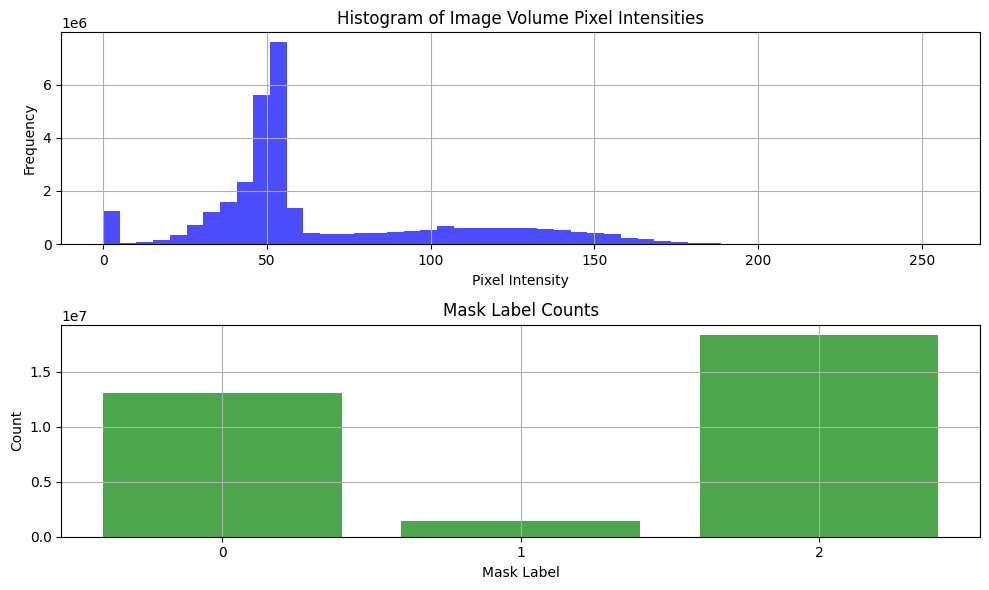

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# Plot histogram for image volume
axes[0].hist(sample_image.ravel(), bins=50, color='blue', alpha=0.7)
axes[0].set_title('Histogram of Image Volume Pixel Intensities')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

# Plot bin count for mask
unique_values, counts = np.unique(sample_mask, return_counts=True)
axes[1].bar(unique_values.astype(str), counts, color='green', alpha=0.7)
axes[1].set_title('Mask Label Counts')
axes[1].set_xlabel('Mask Label')
axes[1].set_ylabel('Count')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [5]:
train_images_path = os.path.join(PATH_DATASET, 'train_images')

# Get all file names in the train_images directory
all_files = os.listdir(train_images_path)

# Filter for TIFF files and extract image IDs
image_ids = sorted([os.path.splitext(f)[0] for f in all_files if f.endswith('.tif')])

print(f"Found {len(image_ids)} image IDs. First 5: {image_ids[:5]}")
print(f"Last 5: {image_ids[-5:]}")

Found 786 image IDs. First 5: ['1004283650', '1006462223', '1013184726', '102536988', '1029212680']
Last 5: ['961304774', '969293709', '975031774', '985841575', '992852942']


## 3D viewer

In [6]:
from ipywidgets import interact, IntSlider, fixed, FloatSlider
from matplotlib.patches import PathPatch, Rectangle
from matplotlib.path import Path
from matplotlib.colors import ListedColormap, BoundaryNorm # Added imports
import matplotlib.patches as mpatches # Added import

# Helper functions from the template
# Note: _draw_line and _set_axes_labels are defined but not used in the template's show_volume
def _draw_line(ax, coords, clr='g'):
    line = Path(coords, [Path.MOVETO, Path.LINETO])
    pp = PathPatch(line, linewidth=3, edgecolor=clr, facecolor='none')
    ax.add_patch(pp)

def _set_axes_labels(ax, axes_x, axes_y):
    ax.set_xlabel(axes_x)
    ax.set_ylabel(axes_y)
    ax.set_aspect('equal', 'box')

_rec_prop = dict(linewidth=5, facecolor='none')

def show_volume(vol, mask_vol, z, y, x, mask_alpha, fig_size=(12, 12)): # Increased fig_size
    fig = plt.figure(figsize=fig_size)
    # Create subplots using fig.add_subplot
    ax00 = fig.add_subplot(2, 2, 1) # Top-left: Axial
    ax01 = fig.add_subplot(2, 2, 2) # Top-right: Sagittal
    ax10 = fig.add_subplot(2, 2, 3) # Bottom-left: Coronal
    ax11 = fig.add_subplot(2, 2, 4, projection='3d') # Bottom-right: 3D view
    v_z, v_y, v_x = vol.shape

    # --- Custom Colormap and Legend Setup for Mask ---
    # Define colors for mask labels: 0=Background, 1=Foreground, 2=Unlabeled
    # Using distinct colors for visualization:
    # 'lightgray' for background (visible in legend, subtle on image)
    # 'yellow' for foreground
    # 'cyan' for unlabeled
    colors = ['lightgray', 'yellow', 'cyan'] # This order maps to 0, 1, 2
    mask_cmap = ListedColormap(colors)
    # Define boundaries for the colormap. Values are centered in the bins.
    # e.g., 0 is between -0.5 and 0.5, 1 is between 0.5 and 1.5, 2 is between 1.5 and 2.5
    bounds = [-0.5, 0.5, 1.5, 2.5]
    mask_norm = BoundaryNorm(bounds, mask_cmap.N)

    # Legend handles
    legend_patches = [
        mpatches.Patch(color='lightgray', label='0: Background'),
        mpatches.Patch(color='yellow', label='1: Foreground'),
        mpatches.Patch(color='cyan', label='2: Unlabeled')
    ]
    # --- End Custom Colormap and Legend Setup ---

    # Axial slice (XY plane - view along Z-axis)
    ax00.imshow(vol[z, :, :], cmap="gray")
    # Overlay mask with adjustable alpha, using custom colormap and normalization
    ax00.imshow(mask_vol[z, :, :], cmap=mask_cmap, norm=mask_norm, alpha=mask_alpha, interpolation='nearest')
    ax00.add_patch(Rectangle((-1, -1), v_x, v_y, edgecolor='r', **_rec_prop))
    _draw_line(ax00, [(x, 0), (x, v_y)], "g") # Green line for sagittal cut
    _draw_line(ax00, [(0, y), (v_x, y)], "b") # Blue line for coronal cut
    ax00.set_title(f"Axial (XY) Slice - Z: {z}")
    # REMOVED: ax00.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0.)

    # Sagittal slice (YZ plane - view along X-axis, transposed for common orientation)
    ax01.imshow(vol[:, :, x].T, cmap="gray")
    # Overlay mask with adjustable alpha, using custom colormap and normalization
    ax01.imshow(mask_vol[:, :, x].T, cmap=mask_cmap, norm=mask_norm, alpha=mask_alpha, interpolation='nearest')
    ax01.add_patch(Rectangle((-1, -1), v_z, v_y, edgecolor='g', **_rec_prop))
    # Red line for axial cut (across Z-axis of transposed image)
    _draw_line(ax01, [(z, 0), (z, v_y)], "r")
    # Blue line for coronal cut (across Y-axis of transposed image)
    _draw_line(ax01, [(0, y), (v_z, y)], "b")
    ax01.set_title(f"Sagittal (YZ) Slice - X: {x}")

    # Coronal slice (XZ plane - view along Y-axis)
    ax10.imshow(vol[:, y, :], cmap="gray")
    # Overlay mask with adjustable alpha, using custom colormap and normalization
    ax10.imshow(mask_vol[:, y, :], cmap=mask_cmap, norm=mask_norm, alpha=mask_alpha, interpolation='nearest')
    ax10.add_patch(Rectangle((-1, -1), v_x, v_z, edgecolor='b', **_rec_prop))
    _draw_line(ax10, [(0, z), (v_x, z)], "r") # Red line for axial cut
    _draw_line(ax10, [(x, 0), (x, v_z)], "g") # Green line for sagittal cut
    ax10.set_title(f"Coronal (XZ) Slice - Y: {y}")

    # --- 3D Plotting for ax11 ---
    # Define coordinates for planes
    Y_grid, X_grid = np.meshgrid(np.arange(v_y), np.arange(v_x))
    Z_grid_cor, X_grid_cor = np.meshgrid(np.arange(v_z), np.arange(v_x))
    Z_grid_sag, Y_grid_sag = np.meshgrid(np.arange(v_z), np.arange(v_y))

    # Plot Axial Plane (XY) at current z
    ax11.plot_surface(X_grid, Y_grid, np.full_like(X_grid, z), color='r', alpha=0.2)
    # Plot Coronal Plane (XZ) at current y
    ax11.plot_surface(X_grid_cor, np.full_like(X_grid_cor, y), Z_grid_cor, color='b', alpha=0.2)
    # Plot Sagittal Plane (YZ) at current x
    ax11.plot_surface(np.full_like(Y_grid_sag, x), Y_grid_sag, Z_grid_sag, color='g', alpha=0.2)

    # Set 3D Axis Labels
    ax11.set_xlabel('X (width)')
    ax11.set_ylabel('Y (height)')
    ax11.set_zlabel('Z (depth)')

    # Set 3D Axis Limits
    ax11.set_xlim([0, v_x])
    ax11.set_ylim([0, v_y])
    ax11.set_zlim([0, v_z])

    # Set View Angle
    ax11.view_init(elev=20, azim=45)
    # Add legend to ax11, positioned at the top center in a single row
    ax11.legend(handles=legend_patches, loc='upper center', bbox_to_anchor=(0.5, 1.0), ncol=len(legend_patches), fancybox=True, shadow=True)
    # --- End 3D Plotting ---

    fig.tight_layout()
    plt.show()

Running and 'Batch'...


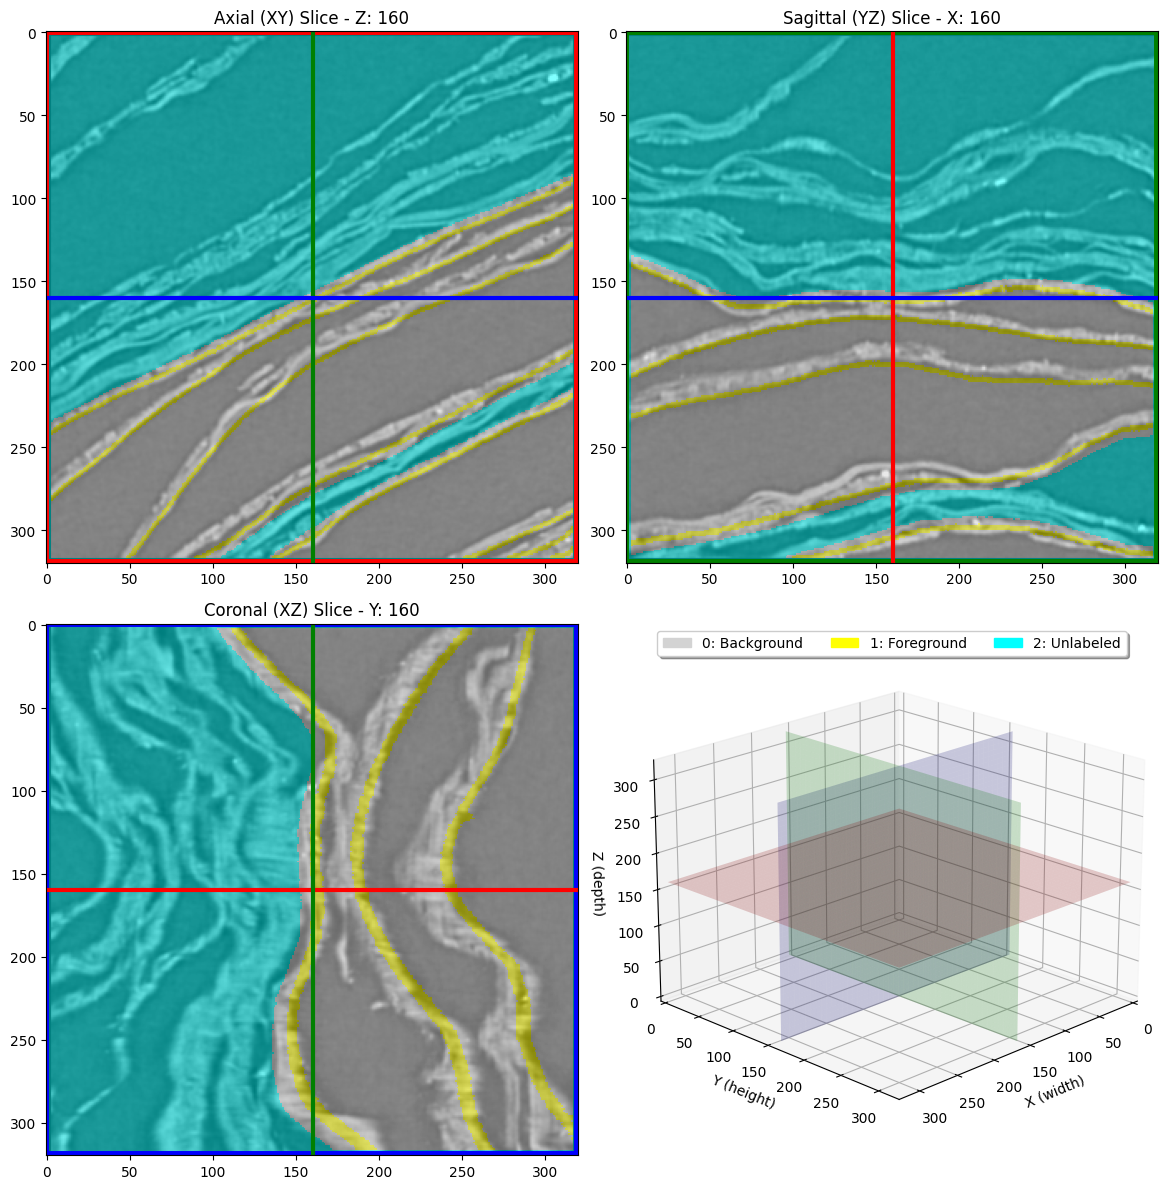

In [7]:
def interactive_show(volume, mask_vol):
    vol_z, vol_y, vol_x = volume.shape
    interact(
        lambda x, y, z, mask_alpha: plt.show(show_volume(volume, mask_vol, z, y, x, mask_alpha)),
        z=IntSlider(min=0, max=vol_z - 1, step=1, value=vol_z // 2, description='Z-slice'),
        y=IntSlider(min=0, max=vol_y - 1, step=1, value=vol_y // 2, description='Y-slice'),
        x=IntSlider(min=0, max=vol_x - 1, step=1, value=vol_x // 2, description='X-slice'),
        mask_alpha=FloatSlider(min=0.0, max=1.0, step=0.05, value=0.3, description='Mask Alpha') # New transparency slider
    )

run_type = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', 'Unknown')
# Make sure sample_image and sample_mask are defined from previous cells
# if 'sample_image' in globals() and 'sample_mask' in globals():
if run_type == "Interactive":
    interactive_show(sample_image, sample_mask)
    print("Interactive 3D viewer created and displayed.")
else:
    print(f"Running and '{run_type}'...")
    vol_z, vol_y, vol_x = sample_image.shape
    show_volume(sample_image, sample_mask, z=vol_z // 2, y=vol_y // 2, x=vol_x // 2, mask_alpha=0.5)

## Demo submission

In [8]:
from tqdm.auto import tqdm
from pathlib import Path

DATA_DIR = Path(PATH_DATASET)
TEST_IMAGES_DIR = DATA_DIR / "test_images"

test_volume_files = sorted([f.name for f in TEST_IMAGES_DIR.glob("*.tif")])
if not test_volume_files:
    raise FileNotFoundError(f"No TIFF files found in {TEST_IMAGES_DIR} for inference.")

test_filenames = []
for test_volume_file in tqdm(test_volume_files):
    volume_path = TEST_IMAGES_DIR / test_volume_file
    volume = tifffile.imread(str(volume_path))
    # Generate random mask with values 0, 1, or ...
    segm = np.random.randint(0, 2, size=volume.shape).astype(np.uint8)
    test_filename = f"{Path(volume_path).stem}.tif"
    tifffile.imwrite(test_filename, segm)
    test_filenames.append(test_filename)

  0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
import zipfile

with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zipf:
    for filename in tqdm(test_filenames, desc="Zipping files"):
        if not os.path.exists(filename):
            print(f"Missing <> {filename}")
            continue
        zipf.write(filename)
        os.remove(filename)

Zipping files:   0%|          | 0/1 [00:00<?, ?it/s]